# 1D CNN ECG Sequence Classifier

1D Convolutional Neural Networks process temporal sequence vectors, sliding kernels across chronological axes to detect localized feature patterns. In medical informatics, 1D CNNs classify electrocardiogram (ECG) waveforms to automate arrhythmia detection. This notebook generates synthetic 1D ECG pulse signals (600 sequences, 100 steps), trains a 1D CNN in PyTorch, and plots loss curves in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, classification_report

# Generate synthetic ECG sequence curves (600 signals, length = 100 steps)
np.random.seed(230)
n_signals = 600
seq_len = 100

X_data, y_data = [], []
for _ in range(n_signals):
    label = np.random.randint(0, 2)
    # Timeline
    t = np.linspace(0, 2*np.pi, seq_len)
    
    # Baseline heart wave (QRS complex approximation)
    wave = np.sin(t) + np.sin(3*t)*0.2
    
    # Class 1 (anomalous arrhythmia) has a sharp spike overlay
    if label == 1:
        spike_idx = np.random.randint(30, 70)
        wave[spike_idx:spike_idx+5] += 3.5 # Anomaly pulse spike
        
    noise = np.random.normal(0, 0.15, seq_len)
    signal = wave + noise
    
    X_data.append(signal)
    y_data.append(label)

X = np.array(X_data) # [600, 100]
y = np.array(y_data) # [600]

# Add channel dimension: shape [600, 1, 100]
X = np.expand_dims(X, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print("Train Signals shape:", X_train_tensor.shape)
print("Test Signals shape: ", X_test_tensor.shape)



Train Signals shape: torch.Size([480, 1, 100])
Test Signals shape:  torch.Size([120, 1, 100])


## 1D CNN Architecture

We implement the convolutional model in PyTorch:
1. **Conv1d Layer**: Input channel=1, output filters=8, kernel size=5.
2. **MaxPool1d**: Pooling down-sampling window size=2.
3. **Linear Head**: Decodes dense features to binary sigmoid targets.



In [2]:
class ECGCNN(nn.Module):
    def __init__(self):
        super(ECGCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(8 * 50, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        features = self.conv(x)
        out = self.fc(features).squeeze(1)
        return out

model = ECGCNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)



## CNN Pipeline Training

We train the 1D CNN for 100 epochs, evaluating loss on train data and prediction recall metrics on test splits.



In [3]:
epochs = 100
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | BCE Training Loss: {loss.item():.4f}")

# Evaluate predictions on test data
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor).numpy()
    binary_preds = (test_preds > 0.5).astype(int)
    
anomaly_recall = recall_score(y_test, binary_preds)
print(f"\nArrhythmia Anomaly Class Test Recall: {anomaly_recall*100:.2f}%")
print("\nClassification Report Summary:")
print(classification_report(y_test, binary_preds, target_names=['Normal', 'Anomaly']))



Epoch  20/100 | BCE Training Loss: 0.0054
Epoch  40/100 | BCE Training Loss: 0.0001
Epoch  60/100 | BCE Training Loss: 0.0000
Epoch  80/100 | BCE Training Loss: 0.0000
Epoch 100/100 | BCE Training Loss: 0.0000

Arrhythmia Anomaly Class Test Recall: 100.00%

Classification Report Summary:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        42
     Anomaly       1.00      1.00      1.00        78

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## ECG Convolutional Classification Diagnostics Plot

We visualize the training loss decay and sample test ECG waveforms with their labels in Matplotlib.



<cell>:21: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



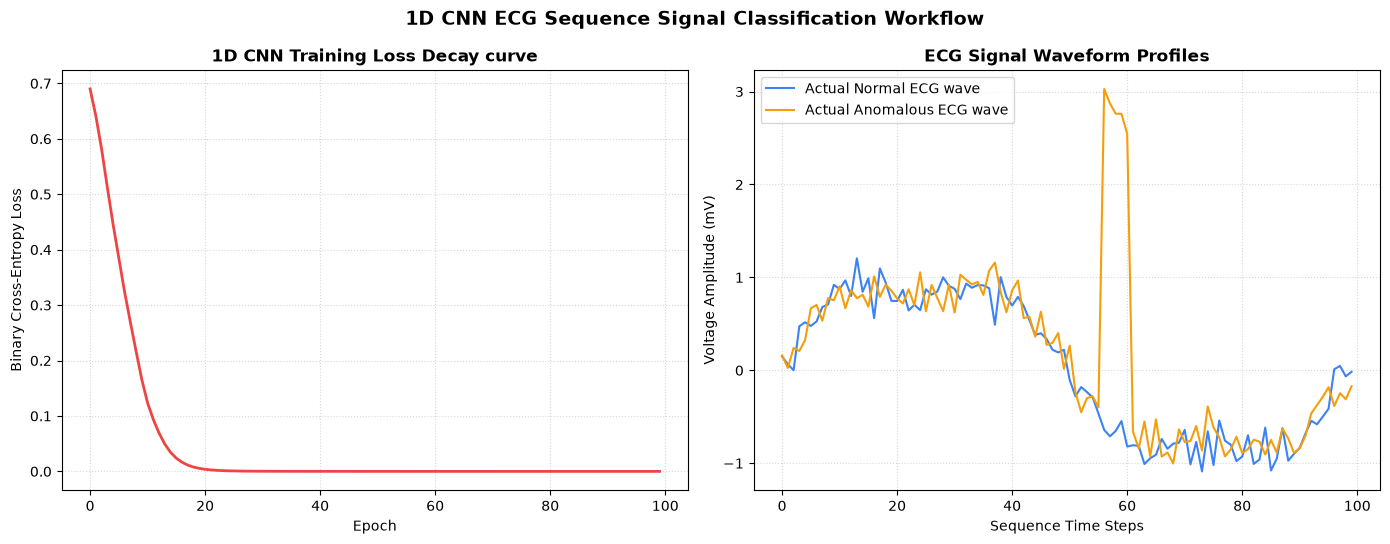

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. BCE Loss curve
ax1.plot(losses, color='#EF4444', linewidth=2.0, label='BCE Loss')
ax1.set_title('1D CNN Training Loss Decay curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Sample normal vs anomalous ECG waveform
ax2.plot(X_test[y_test == 0][0, 0], color='#3B82F6', label='Actual Normal ECG wave')
ax2.plot(X_test[y_test == 1][0, 0], color='#F59E0B', label='Actual Anomalous ECG wave')
ax2.set_title('ECG Signal Waveform Profiles', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sequence Time Steps')
ax2.set_ylabel('Voltage Amplitude (mV)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('1D CNN ECG Sequence Signal Classification Workflow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
